In [78]:
import pandas as pd 
customers=pd.read_csv('/Users/mohammed/Desktop/CHPTER 2/addresses.csv')
cities=pd.read_csv('/Users/mohammed/Desktop/CHPTER 2/cities.csv')
print(customers.shape)


(100000, 3)


In [79]:
customers= customers.dropna(subset="address")


In [80]:
customers

,company_id,address,total_spend
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600
...,...,...,...
99995,99996,"KNAPP HOUSE,\nSELSLEY WEST,\nSTROUD,\nGLOUCEST...",4600
99996,99997,"20 The Broadway, Hampton Court,\nWay, Thames D...",4100
99997,99998,"MARLAND HOUSE,\n13 HUDDERSFIELD ROAD,\nBARNSLE...",5600
99998,99999,"4 MOUNT SCAR VIEW,\nSCHOLES,\nHOLMFIRTH HUDDER...",4600


In [81]:
customers['total_spend'].describe()

count    99032.000000
mean      4951.673197
std       1500.642398
min          0.000000
25%       3900.000000
50%       5000.000000
75%       6000.000000
max      11700.000000
Name: total_spend, dtype: float64

In [82]:

    for address in customers['address'].head():
        print(address, '\n')

APARTMENT 2,
52 BEDFORD ROAD,
LONDON,
ENGLAND,
SW4 7HJ 

107 SHERINGHAM AVENUE,
LONDON,
N14 4UJ 

43 SUNNINGDALE,
YATE,
BRISTOL,
ENGLAND,
BS37 4HZ 

HAWESWATER HOUSE,
LINGLEY MERE BUSINESS PARK,
LINGLEY GREEN AVENUE,
GREAT SANKEY, WARRINGTON,
WA5 3LP 

AMBERFIELD BARN HOUSE AMBER LANE,
CHART SUTTON,
MAIDSTONE,
ENGLAND,
ME17 3SF 



In [83]:
customers['address_cleaned'] =customers['address'].str.upper()


In [84]:
len(customers[customers['address_cleaned'].str.contains('LONDON')])


21768

In [85]:
len(customers[customers['address_cleaned'].str.contains('LONDON,')])

20831

In [86]:
customers['address_lines']=(
    customers['address_cleaned'].str.split(',\n').apply(len)
)

In [87]:
customers['address_lines'].value_counts().sort_index()

address_lines
1        6
2       52
3     3284
4    35850
5    45931
6    13909
Name: count, dtype: int64

In [88]:
customers

,company_id,address,total_spend,address_cleaned,address_lines
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",3
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",5
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",5
...,...,...,...,...,...
99995,99996,"KNAPP HOUSE,\nSELSLEY WEST,\nSTROUD,\nGLOUCEST...",4600,"KNAPP HOUSE,\nSELSLEY WEST,\nSTROUD,\nGLOUCEST...",5
99996,99997,"20 The Broadway, Hampton Court,\nWay, Thames D...",4100,"20 THE BROADWAY, HAMPTON COURT,\nWAY, THAMES D...",4
99997,99998,"MARLAND HOUSE,\n13 HUDDERSFIELD ROAD,\nBARNSLE...",5600,"MARLAND HOUSE,\n13 HUDDERSFIELD ROAD,\nBARNSLE...",6
99998,99999,"4 MOUNT SCAR VIEW,\nSCHOLES,\nHOLMFIRTH HUDDER...",4600,"4 MOUNT SCAR VIEW,\nSCHOLES,\nHOLMFIRTH HUDDER...",5


In [91]:
print(customers.loc[customers['address_lines']==1,'address_cleaned'])
print(
    customers[customers['address_lines'] == 2]
        .sample(5, random_state=42)['address_cleaned']
)

17789                      FALKIRK
31897                   HADDINGTON
61750          CREAG BHAITHEACHAIN
75330                     NEWMILNS
78045    REDCLOAK FARM, STONEHAVEN
90897     REFER TO PARENT REGISTRY
Name: address_cleaned, dtype: object
39443                                    FORFAR,\nANGUS
80846                        12 HOPE STREET,\nEDINBURGH
95979    BRANCH REGISTRATION,\nREFER TO PARENT REGISTRY
23563    BRANCH REGISTRATION,\nREFER TO PARENT REGISTRY
81155                             PO BOX 2230,\nGLASGOW
Name: address_cleaned, dtype: object


In [44]:
cities

,City
0,England
1,Bath
2,Birmingham*
3,Bradford*
4,Brighton & Hove
...,...
75,Newport
76,St Asaph
77,St Davids
78,Swansea*


In [92]:
countries_to_remove = ['England', 'Scotland', 'Wales', 'Northern Ireland']
print(len(cities))

cities_to_remove = cities[cities['City'].isin(countries_to_remove)].index

cities = cities.drop(index=cities_to_remove)
print(len(cities))

cities['City'] = cities['City'].str.replace('*','', regex=False)

cities['City'] = cities['City'].str.upper()
cities.head()



80
76


,City
1,BATH
2,BIRMINGHAM
3,BRADFORD
4,BRIGHTON & HOVE
5,BRISTOL


In [93]:
for city in cities['City'].values:
    customers.loc[customers['address_cleaned'].str.contains(f'\n{city},'),'City'] = city

# This line fills NA values in the 'City' column with 'OTHER'
customers['City'] = customers['City'].fillna('OTHER')
customers.head()

,company_id,address,total_spend,address_cleaned,address_lines,City
0,1,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5700,"APARTMENT 2,\n52 BEDFORD ROAD,\nLONDON,\nENGLA...",5,LONDON
1,2,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",4700,"107 SHERINGHAM AVENUE,\nLONDON,\nN14 4UJ",3,LONDON
2,3,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5900,"43 SUNNINGDALE,\nYATE,\nBRISTOL,\nENGLAND,\nBS...",5,BRISTOL
3,4,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",7200,"HAWESWATER HOUSE,\nLINGLEY MERE BUSINESS PARK,...",5,OTHER
4,5,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",4600,"AMBERFIELD BARN HOUSE AMBER LANE,\nCHART SUTTO...",5,OTHER


In [94]:
customers['City'].value_counts().head(20)

City
OTHER            54458
LONDON           20762
MANCHESTER        1902
BIRMINGHAM        1866
GLASGOW           1273
BRISTOL           1150
LEEDS             1040
EDINBURGH         1038
LEICESTER          905
NOTTINGHAM         838
LIVERPOOL          838
CARDIFF            797
SHEFFIELD          706
COVENTRY           553
MILTON KEYNES      493
SOUTHAMPTON        477
NORWICH            449
BRADFORD           417
BELFAST            416
PRESTON            406
Name: count, dtype: int64

In [95]:
sample_Other = customers[customers['City']=='OTHER'].sample(5,random_state=42)

for address in sample_Other['address_cleaned'].values:
    print(address,'\n')


82 CROSSE COURTS,
BASILDON,
ENGLAND,
SS15 5JE 

70 NORMAN CRESCENT,
PINNER,
ENGLAND,
HA5 3QL 

23 STATION ROAD,
GERRARDS CROSS,
BUCKINGHAMSHIRE,
ENGLAND,
SL9 8ES 

5 STEWARTS PARK AVENUE,
MARTON,
MIDDLESBROUGH,
CLEVELAND,
UNITED KINGDOM,
TS4 3FD 

FIRST FLOOR,
6 YORK STREET,
TWICKENHAM,
ENGLAND,
TW1 3LD 



In [96]:
set(cities['City']) - set(customers['City'])

{'KINGSTON-UPON-HULL'}

In [97]:
customers[customers['address_cleaned'].str.contains('\nHULL,')]

,company_id,address,total_spend,address_cleaned,address_lines,City
455,456,"349 BEVERLEY ROAD,\nANLABY,\nHULL,\nENGLAND,\n...",3800,"349 BEVERLEY ROAD,\nANLABY,\nHULL,\nENGLAND,\n...",5,OTHER
1139,1140,"90 CALVERT LANE,\nHULL,\nENGLAND,\nHU4 6BJ",6000,"90 CALVERT LANE,\nHULL,\nENGLAND,\nHU4 6BJ",4,OTHER
1822,1823,"ACER GLADE BLACK TUP LANE,\nARNOLD,\nHULL,\nEN...",4600,"ACER GLADE BLACK TUP LANE,\nARNOLD,\nHULL,\nEN...",5,OTHER
1831,1832,"10 GORDON STREET,\nHULL,\nENGLAND,\nHU3 3HN",5300,"10 GORDON STREET,\nHULL,\nENGLAND,\nHU3 3HN",4,OTHER
1921,1922,"70 WRIGHT STREET,\nHULL,\nENGLAND,\nHU2 8JD",6100,"70 WRIGHT STREET,\nHULL,\nENGLAND,\nHU2 8JD",4,OTHER
...,...,...,...,...,...,...
98479,98480,"31-38 QUEEN STREET,\nHULL,\nENGLAND,\nHU1 1UU",4500,"31-38 QUEEN STREET,\nHULL,\nENGLAND,\nHU1 1UU",4,OTHER
98886,98887,"13 SALMON GROVE,\nHULL,\nEAST YORKSHIRE,\nENGL...",5000,"13 SALMON GROVE,\nHULL,\nEAST YORKSHIRE,\nENGL...",5,OTHER
99196,99197,"22 19TH AVENUE,\nHULL,\nENGLAND,\nHU6 8HF",5900,"22 19TH AVENUE,\nHULL,\nENGLAND,\nHU6 8HF",4,OTHER
99434,99435,"F14 THE BLOC SPRINGFIELD WAY,\nANLABY,\nHULL,\...",3100,"F14 THE BLOC SPRINGFIELD WAY,\nANLABY,\nHULL,\...",6,OTHER


In [98]:
customers.loc[customers['address_cleaned'].str.contains('\nHULL,'),'City']='HULL'

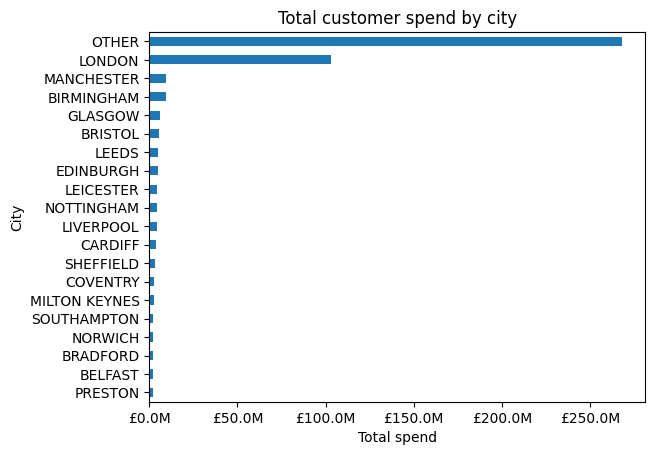

In [99]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

def millions(x, pos): #1
    return '£%1.1fM' % (x * 1e-6)  # This line needed proper indentation

formatter = FuncFormatter(millions)
fig, axis = plt.subplots()
top_20_spend = (
    customers
    .groupby("City")
    ["total_spend"].sum()
    .sort_values(ascending=False) #2
    .head(20)
    .sort_values(ascending=True) #3
)
top_20_spend.plot.barh(ax=axis)
axis.xaxis.set_major_formatter(formatter)
axis.set(
    title="Total customer spend by city",
    xlabel="Total spend"
)
plt.show()

In [100]:
print('total spend for all customers ')
print(customers['total_spend'].sum())

print('total spend for LONDON customers')
print(customers.loc[customers['City']=='LONDON','total_spend'].sum())

print('total spend outsid LONDON')
print(customers.loc[customers['City']!='LONDON','total_spend'].sum())

print("Total spend outside London (excluding OTHER):")
print(customers.loc[customers["City"].isin(["LONDON", "OTHER"]) == False,"total_spend"].sum())



total spend for all customers 
490374100
total spend for LONDON customers
103042800
total spend outsid LONDON
387331300
Total spend outside London (excluding OTHER):
119468400


In [102]:
customers.to_csv('/Users/mohammed/Desktop/CHPTER 2/addresses_clean.csv')